In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
data = pd.read_csv("EasyVisa.csv")

In [38]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [45]:
data.drop("case_id",axis= 1,inplace = True)

In [6]:
data.shape

(25480, 11)

In [7]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [51]:
numeric_features = [column for column in data.columns if data[column].dtype != "O" ]
categorical_features = [column for column in data.columns if data[column].dtype == "O" ]

In [11]:
numeric_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

<Axes: xlabel='no_of_employees', ylabel='Count'>

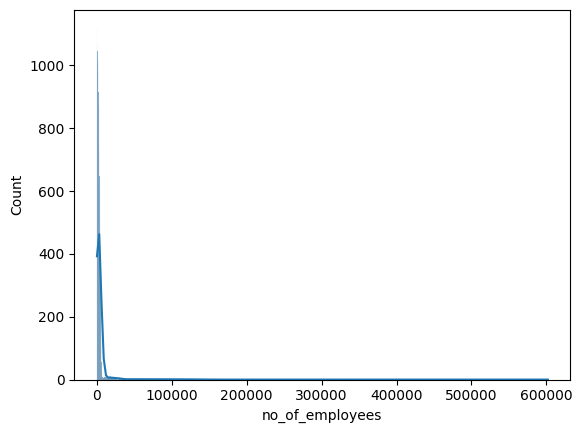

In [13]:
sns.histplot(data["no_of_employees"],kde=True)

In [14]:
data["no_of_employees"].describe()

count     25480.000000
mean       5667.043210
std       22877.928848
min         -26.000000
25%        1022.000000
50%        2109.000000
75%        3504.000000
max      602069.000000
Name: no_of_employees, dtype: float64

In [39]:
data = data[data["no_of_employees"]>0]

In [40]:
data.shape

(25447, 12)

In [ ]:
from datetime import datetime

In [41]:
data.loc[:,"company_age"]=datetime.now().year - data["yr_of_estab"]

In [42]:
data["company_age"]

0         19
1         24
2         18
3        129
4         21
        ... 
25475     18
25476     20
25477    116
25478    139
25479     66
Name: company_age, Length: 25447, dtype: int64

In [43]:
data.drop("yr_of_estab",axis = 1,inplace = True)

In [46]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,19
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,24
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,18
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,129
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,21


In [78]:
numeric_features = [column for column in data.columns if data[column].dtype != "O" ]
numeric_features.remove("case_status")

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score


In [73]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("scaler",OneHotEncoder())
])


In [86]:
preprocessing= ColumnTransformer([
    ("num",numerical_pipeline,numeric_features),
    ("cat",ordinal_pipeline,categorical_features),

])

In [55]:
dic = {
    "Certified": 1,
    "Denied":0
}

In [59]:
data["case_status"]=data["case_status"].replace(dic)
x = data.drop("case_status",axis = 1)
y = data["case_status"]

In [68]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,shuffle=True,test_size=0.25)

In [69]:
x_train.shape

(19085, 10)

In [70]:
y_train.shape

(19085,)

In [92]:
def evaluate(actual,predict):

    accuracy = accuracy_score(actual,predict)

    confusion = confusion_matrix(actual,predict)

    precision = precision_score(actual,predict)

    f1 = f1_score(actual,predict)

    recall = recall_score(actual,predict)

    return accuracy,confusion,precision,f1,recall

In [89]:
models = {
    "Logistic_regression":LogisticRegression(),
    "svc":SVC(),
    "Decision_Tree":DecisionTreeClassifier(),
    "Random_forest":RandomForestClassifier()

}
print(len(models))

4


In [90]:
# Evaluate models

def evaluate_model(x,y,models):

    # separate dataset into train and test

    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42,shuffle=True)

    models_list = []

    accuracy_list_train = []

    accuracy_list_test = []

    for i in range(len(models)):

        model = list(models.values())[i]
        
        training_pipeline =  Pipeline([

           ("preprocessing",preprocessing),

            ("model",model)])
        

        training_pipeline.fit(x_train,y_train)

        # making predictions 

        y_train_pred = training_pipeline.predict(x_train)
        y_test_pred = training_pipeline.predict(x_test)

        # training set performances

        model_train_accuracy,modle_train_confusion,model_train_precision,\
        model_train_f1,model_train_recall=evaluate(y_train,y_train_pred)


        # test set performances
        
        model_test_accuracy,modle_test_confusion,model_test_precision,\
        model_test_f1,model_test_recall=evaluate(y_test,y_test_pred) 

        
        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print("model performance for training Data ")
        print("- Accuracy {:.4f}".format(model_train_accuracy))
        accuracy_list_train.append(model_train_accuracy)
        print("- Confusion_matrix".format(modle_train_confusion))
        print("- precision{:.4f}".format(model_train_precision))
        print("- f1 {:.4f}".format(model_train_f1))
        print("- Recall{:.4f}".format(model_train_recall))

        print("----------------------------")


        print("model performance for test Data ")
        print("- Accuracy {:.4f}".format(model_test_accuracy))
        accuracy_list_test.append(model_test_accuracy)
        print("- Confusion_matrix".format(modle_test_confusion))
        print("- precision{:.4f}".format(model_test_precision))
        print("- f1 {:.4f}".format(model_test_f1))
        print("- Recall{:.4f}".format(model_test_recall))


    report = pd.DataFrame(list(zip(models_list,accuracy_list_test,accuracy_list_train)),columns=["Model","Test_Accuracy","Train_Accuracy"])

    return report 

    

In [93]:
evaluating_model = evaluate_model(x,y,models)

Logistic_regression
model performance for training Data 
- Accuracy 0.7415
- Confusion_matrix
- precision0.7676
- f1 0.8206
- Recall0.8815
----------------------------
model performance for test Data 
- Accuracy 0.7273
- Confusion_matrix
- precision0.7545
- f1 0.8083
- Recall0.8703
svc
model performance for training Data 
- Accuracy 0.7607
- Confusion_matrix
- precision0.7900
- f1 0.8308
- Recall0.8760
----------------------------
model performance for test Data 
- Accuracy 0.7399
- Confusion_matrix
- precision0.7710
- f1 0.8141
- Recall0.8622
Decision_Tree
model performance for training Data 
- Accuracy 1.0000
- Confusion_matrix
- precision1.0000
- f1 1.0000
- Recall1.0000
----------------------------
model performance for test Data 
- Accuracy 0.6478
- Confusion_matrix
- precision0.7311
- f1 0.7346
- Recall0.7382
Random_forest
model performance for training Data 
- Accuracy 0.9999
- Confusion_matrix
- precision1.0000
- f1 1.0000
- Recall0.9999
----------------------------
model perfo

In [94]:
evaluating_model

,Model,Test_Accuracy,Train_Accuracy
0,Logistic_regression,0.727287,0.741525
1,svc,0.739862,0.760702
2,Decision_Tree,0.647752,1.000000
3,Random_forest,0.707953,0.999948
